# MCS Selection - Final Analysis Notebook

This notebook loads trained models and generates final analysis plots for the project.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Import project modules
sys.path.append(str(Path('..').resolve()))
from training.config import set_global_seed, GLOBAL_SEED
from models.baselines import get_model
from evaluation.visualization import set_plot_style, plot_confusion_matrix, plot_attention_heatmaps
from evaluation.metrics import load_metrics_file

set_global_seed(GLOBAL_SEED)
set_plot_style()
print('Project loaded successfully!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project loaded successfully!


In [6]:
import os
print(os.listdir('../results/metrics'))

['attention_test_metrics.json', 'attention_training_metrics.json']


## Load All Model Metrics

In [14]:
from evaluation.compare_baselines import load_all_model_metrics
from pathlib import Path
import sys
import os

# Fix path
sys.path.append(str(Path('..').resolve()))

metrics_path = Path('../results/metrics')

# 🔥 Automatically extract model names from files
files = os.listdir(metrics_path)
model_names = list(set(f.split('_')[0] for f in files if f.endswith('_test_metrics.json')))

print("Detected models:", model_names)

all_metrics = load_all_model_metrics(metrics_path, model_names)

print('Loaded metrics for models:', list(all_metrics.keys()))

# Display
for model, data in all_metrics.items():
    metrics = data.get("metrics", {})   # ✅ extract nested dict

    acc = metrics.get('test_accuracy', 0)
    throughput = metrics.get('throughput_ratio', 0)
    latency = metrics.get('inference_latency_ms', None)

    print(f"\n{model.upper()}:")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"  Throughput: {throughput:.4f}")
    print(f"  Latency: {latency if latency is not None else 'N/A'} ms")

Detected models: ['attention']
[Info] Loaded test metrics for attention
Loaded metrics for models: ['attention']

ATTENTION:
  Accuracy: 96.96%
  Throughput: 0.9924
  Latency: N/A ms


## Per-Class Accuracy Bar Chart

Saved class accuracy plot to: ../results/plots/class_accuracy_comparison.png


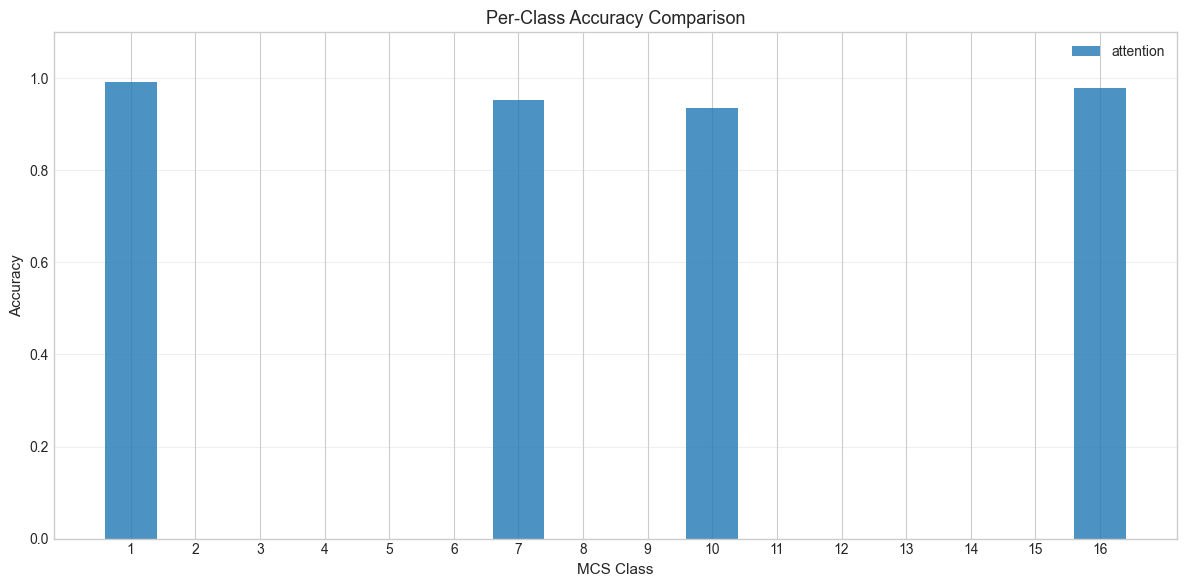

In [16]:
from evaluation.visualization import plot_class_accuracy_comparison

class_accuracies = {}

for model_name, data in all_metrics.items():
    per_class = data.get('per_class_accuracy')

    if per_class is not None:
        class_accuracies[model_name] = per_class
    else:
        print(f"[Warning] No per-class accuracy for {model_name}")

# Only plot if data exists
if class_accuracies:
    plot_class_accuracy_comparison(
        class_accuracies,
        save_path='../results/plots/class_accuracy_comparison.png'
    )
else:
    print("No class accuracy data available to plot")

## Attention Visualization (for Attention Model Only)

Number of attention layers: 2
Attention weights shape (layer 0): torch.Size([32, 4, 10, 10])
Saved attention heatmaps to: ..\results\plots\attention_heatmaps_sample.png


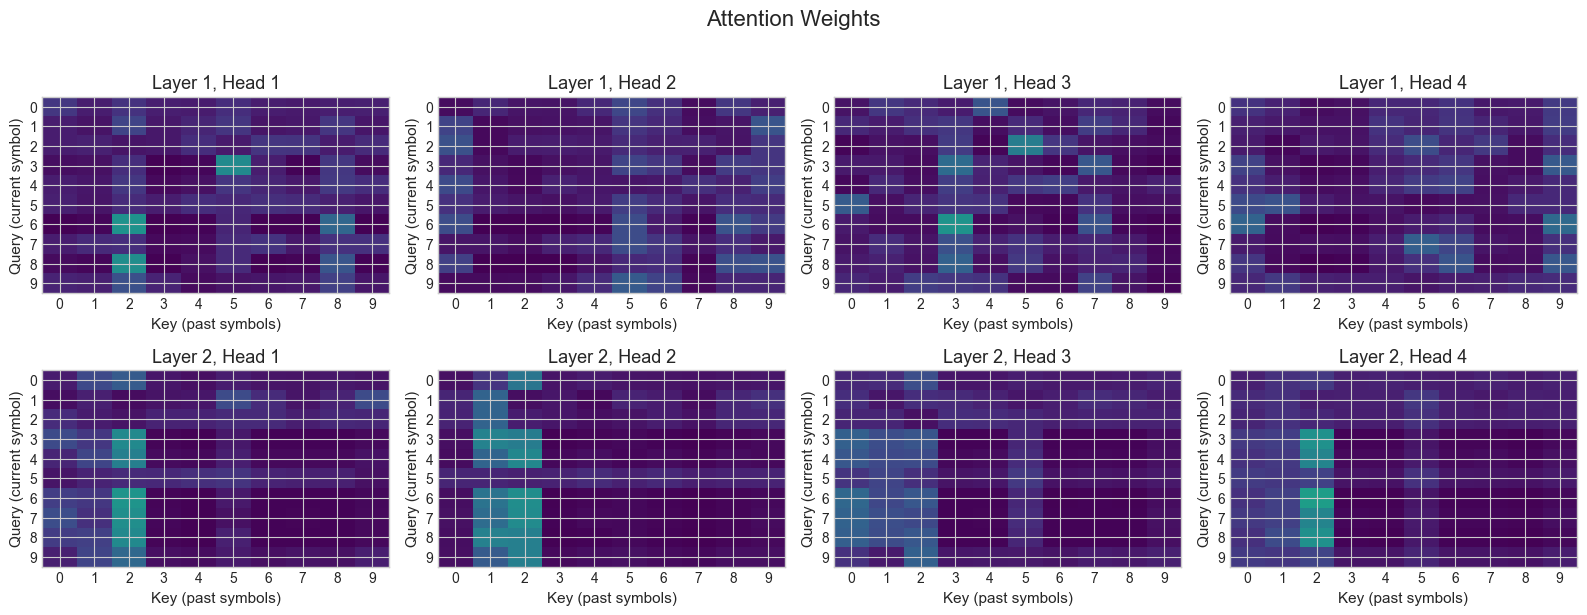

In [17]:
import torch
from training.data_generator import load_split
from pathlib import Path

# Fix paths
DATA_PATH = Path('../data/test')
CHECKPOINT_PATH = Path('../results/attention/checkpoints/best_model.pt')
PLOT_PATH = Path('../results/plots/attention_heatmaps_sample.png')

# Load test data
test_channels, test_labels = load_split(DATA_PATH)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.from_numpy(test_channels).float(),
        torch.from_numpy(test_labels).long()
    ),
    batch_size=32,
    shuffle=False
)

channels, labels = next(iter(test_loader))

# Load model
from models.attention_mcs import AttentionMCSModel
from training.config import AttentionModelConfig

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# Initialize model (pass config if required)
model = AttentionMCSModel().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Move data to device
channels = channels.to(device)

# Get attention weights
with torch.no_grad():
    logits, attn_weights_list = model.get_attention_weights(channels)

print(f'Number of attention layers: {len(attn_weights_list)}')
print(f'Attention weights shape (layer 0): {attn_weights_list[0].shape}')

# Plot
from evaluation.visualization import plot_attention_heatmaps

plot_attention_heatmaps(
    attn_weights_list,
    sample_idx=0,
    n_heads_to_plot=4,
    save_path=str(PLOT_PATH)
)

## Training Curves

Saved training plot to: ../results/plots/attention_training_history.png


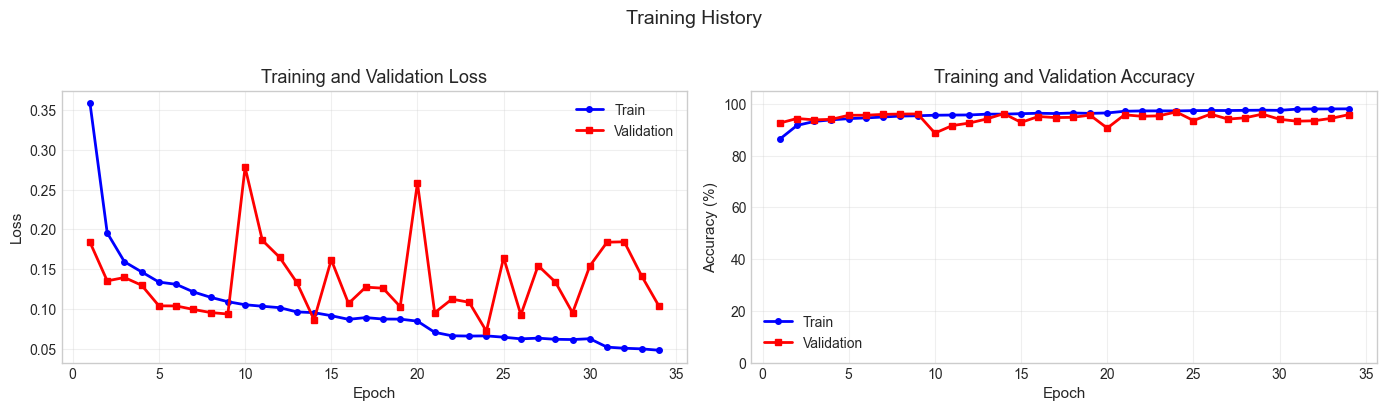

In [18]:
from evaluation.visualization import plot_training_history
import json

# Load training history
history_path = Path('../results/attention/training_history.json')
if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    plot_training_history(history, save_path='../results/plots/attention_training_history.png')

## Final Results Table

In [21]:
from evaluation.metrics import summarize_metrics_comparison
import pandas as pd
from pathlib import Path

# Generate summary
summary = summarize_metrics_comparison(all_metrics)

# Create DataFrame safely
df_summary = pd.DataFrame(summary).T   # ✅ no index forcing

print('\nFinal Results Summary:')
print(df_summary.round(4))

# Ensure directory exists
output_path = Path('../results/plots/comparison_summary.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save CSV
df_summary.to_csv(output_path)

print(f'\nSummary saved to {output_path}')


Final Results Summary:
                             0
test_accuracy           0.9696
test_top3_accuracy         1.0
throughput_ratio      0.992389
inference_latency_ms      None

Summary saved to ..\results\plots\comparison_summary.csv
